<div style="text-align: center">
<img src="https://github.com/LinkedEarth/Logos/blob/master/PyleoTUPS/pyleotups_logo.png?raw=true" alt="PyleoTUPS logo" width="400">
</div>

# Obtaining Lake Records from Australia over the Common Era

## Authors

Georgina Falser [![ORCID](https://img.shields.io/badge/ORCID-0000--0001--8567--7413-A6CE39?logo=orcid)](https://orcid.org/0000-0001-8567-7413), Deborah Khider [![ORCID](https://img.shields.io/badge/ORCID-0000--0001--7501--8430-A6CE39?logo=orcid)](https://orcid.org/0000-0001-7501-8430), Dhiren Oswal [![ORCID](https://img.shields.io/badge/ORCID-0009--0001--2495--2626-A6CE39?logo=orcid)](https://orcid.org/0009-0001-2495-2626)


## Preamble

The goal of this tutorial is to demonstrate how `PyleoTUPS` can be used in scientific studies. In this case, we are interested in gathering lake records from Australia over the Common Era from the NOAA NCEI repository. Once queried, we will map the location of these records and plot the timeseries using the [`Pyleoclim` package](https://pyleoclim-util.readthedocs.io/en/latest/).  


### Goals

 - Search for datasets on NOAA NCEI
 - Clean up the resulting search results
 - Load the data into `pyleoclim.GeoSeries` objects
 - Map the resulting results
 - Plot each timeseries

### Pre-requisites

- A familiarity with the [`NOAADataset` object](02_a_NOAAObject.ipynb) and how to [perform queries on NOAA NCEI](02_c_NOAASearch.ipynb)
- A familiarity with the [`Pyleoclim` software package](https://pyleoclim-util.readthedocs.io/en/latest/) and its [`GeoSeries` object](https://linked.earth/PyleoTutorials/notebooks/L0_working_with_geoseries.html). 

### Reading time

15 min

Let's import our packages!

In [1]:
import pyleotups as pt
import pandas as pd
import pyleoclim as pyleo
import numpy as np

## Querying NOAA NCEI

We want to find all the datasets available through NOAA NCEI corresponding to a data type of Paleolimnology, located between 10-45°S and 110-160°E (roughly corresponding to Australia), and covering the last 2000 years:

In [2]:
## set some variable values
datatype = 13 # we want lakes
# geography
minlat = -45
maxlat = -10
minlon = 110
maxlon = 160
# time
earliest_year = 0
latest_year = 2000
time_format = 'CE'
time_method = 'overAny' 

# make the query
ds = pt.NOAADataset()
res = ds.search_studies(data_type_id = datatype,
                        min_lat =minlat,
                        max_lat = maxlat,
                        min_lon = minlon,
                        max_lon = maxlon,
                        earliest_year = earliest_year,
                        latest_year = latest_year,
                        time_format = time_format,
                        time_method = time_method,
                        limit = 500)


[2026-05-15 14:01:36,682][INFO] - search_studies: Limit set to 500.
[2026-05-15 14:01:36,683][INFO] - search_studies: Input Query includes geographical bounds. Inspect the results to ensure they match your intended region as one study can contain sites across various parts of the world.


Request URL: https://www.ncei.noaa.gov/access/paleo-search/study/search.json?dataTypeId=13&dataPublisher=NOAA&limit=500&minLat=-45&maxLat=-10&minLon=110&maxLon=160&earliestYear=0&latestYear=2000&timeFormat=CE&timeMethod=overAny


Parsing NOAA studies: 100%|██████████| 19/19 [00:00<00:00, 1502.57it/s]
[2026-05-15 14:01:40,308][INFO] - Retrieved 19 studies.


We have 19 potential candidates. Let's have a look at the first ten:

In [3]:
display(res)

,StudyID,XMLID,StudyName,DataType,EarliestYearBP,MostRecentYearBP,EarliestYearCE,MostRecentYearCE,"Coverage [S, N, W, E]",StudyNotes,ScienceKeywords,Investigators,Publications,Sites,Funding
0,12203,10267,2000 Year Precipitation-Based Southern Oscilla...,CLIMATE RECONSTRUCTIONS,1900,-5,50,1955,"(-90.0, 90.0, -180.0, 180.0)",Reconstruction of a precipitation-based Southe...,[Atmospheric and Oceanic Circulation Patterns ...,"Hong Yan, Liguang Sun, Yuhong Wang, Wen Huang,...","[{'Author': 'Yan, H., L. Sun, Y. Wang, W. Huan...","[[{'DataTableID': '20526', 'DataTableName': 'S...",[{'fundingAgency': 'National Natural Science F...
1,22315,20388,2000 Year Tropical Rainfall Reconstructions,CLIMATE RECONSTRUCTIONS,2000,-50,-50,2000,"(-30.0, 30.0, -180.0, 180.0)",Composite reconstruction of low latitude rainf...,[Precipitation Reconstruction],"Franziska Lechleitner, Sebastian Breitenbach, ...","[{'Author': 'Franziska A. Lechleitner, Sebasti...","[[{'DataTableID': '33444', 'DataTableName': 'L...","[{'fundingAgency': 'European Union', 'fundingG..."
2,22411,20588,"Blue Lake, South Australia 6,000 Year Ostracod...",PALEOLIMNOLOGY,5690,5,-3740,1945,"(-37.014087, -37.014087, 140.012913, 140.012913)","Ostracod geochemical (Mg/Ca, Sr/Ca, Na/Ca) and...",None,"Chris Gouramanis, Daniel Wilkins, Patrick De D...","[{'Author': 'Chris Gouramanis, Daniel Wilkins,...","[[{'DataTableID': '33534', 'DataTableName': 'B...",[{'fundingAgency': 'Australian Research Counci...
3,20452,18259,"Duckhole Lake, Tasmania 950 Year Sediment Refl...",PALEOLIMNOLOGY,883,-58,1067,2008,"(-43.3647, -43.3647, 146.875, 146.875)","Sediment reflectance data (650-700 nm trough, ...",[Air Temperature Reconstruction],"Krystyna Saunders, Martin Grosjean, Dominic Ho...","[{'Author': 'KM Saunders, M Grosjean, DA Hodgs...","[[{'DataTableID': '31156', 'DataTableName': 'D...","[{'fundingAgency': 'European Union', 'fundingG..."
4,30799,72496,Eagle Tarn and Platypus Tarn Air Temperature R...,CLIMATE RECONSTRUCTIONS,15862,29,-13912,1921,"(-42.6799, -42.6734, 146.5868, 146.5914)",This dataset was contributed as part of the Te...,[Air Temperature Reconstruction],"Andrew Rees, Les Cwynar","[{'Author': 'Kaufman, D., McKay, N., Routson, ...","[[{'DataTableID': '43353', 'DataTableName': 'E...",[]
5,20529,18345,Global Holocene Paleodust Database,LOESS AND PALEOSOL,12000,0,-10050,1950,"(-90.0, 90.0, -180.0, 180.0)",Mineral dust data (dust mass accumulation rate...,None,Samuel Albani,"[{'Author': 'S. Albani, N.M. Mahowald, G. Winc...","[[{'DataTableID': '31279', 'DataTableName': 'A...",[{'fundingAgency': 'US National Science Founda...
6,5495,620,"Global Lake-Level Variations from 18,000 to 0 ...",LAKE LEVELS,20000,0,-18050,1950,"(-45.5, 78.49, -163.25, 176.73)",Lake status determined at 1000-year intervals ...,"[hydrology, trends]","Frances Alayne Street-Perrott, None Marchand, ...","[{'Author': 'Street-Perrott, F.A., D.S. Marcha...","[[{'DataTableID': '8975', 'DataTableName': 'La...",[]
7,37158,78359,"Lake Barrine, Australia TOC and Itrax Data Ove...",PALEOLIMNOLOGY,18358,1445,-16408,505,"(-17.25, -17.25, 145.64, 145.64)","Provided Keywords: northeastern Australia, bul...","[Younger Dryas, Precipitation Reconstruction]","Michael Bird, Ting Li","[{'Author': 'Li, T., Wurster, C.M., Haig, J., ...","[[{'DataTableID': '49839', 'DataTableName': 'B...",[{'fundingAgency': 'Australian Research Counci...
8,38232,79380,"Lake Barrine, NE Australia brGDGT Data since 1...",PALEOLIMNOLOGY,18305,100,-16355,1850,"(-17.25, -17.25, 145.64, 145.64)",BrGDGTs from surface and downcore sediments in...,None,"Michael Bird, Ting Li","[{'Author': 'Li, Ting, Rainy Comley, Enlou Zha...","[[{'DataTableID': '50805', 'DataTableName': 'B...",[{'fundingAgency': 'Australian Research Counci...
9,22430,20598,"Lake Keilambete, SE Australia Holocene Sedimen...",PALEOLIMNOLOGY,9550,-54,-7600,2004,"(-38.207, -38.207, 142.878, 142.878)",Multiproxy Holocene sediment data and lake lev...,[hydrology],"Daniel Wilkins, Patrick De Deckker, L. Keit

In [4]:
for item in res['DataType'].unique():
    print(item)

CLIMATE RECONSTRUCTIONS
PALEOLIMNOLOGY
LOESS AND PALEOSOL
LAKE LEVELS
CLIMATE FORCING
PALEOCEANOGRAPHY


Lots of things to unpack here!

1. Even though we specified a data type ID corresponding to Paleolimnology, other data types also appear in the results. This happens because the query operates at the variable level: a dataset may be assigned one data type, but individual variables within it can belong to a different type (in this case, Paleolimnology).

2. Some studies also fall outside the specified geographical range. This is likely because one site lies within the Australian boundary while other sites in the same study are more globally distributed. NOAA returns the full study through its API, and it is not possible to access individual sites through the API.

## Database filtering

Let's have a look at the [geographical metadata](https://pyleotups.readthedocs.io/en/latest/api.html#pyleotups.core.NOAADataset.NOAADataset.get_geo) and see if some of our intuition is correct:

In [5]:
df_geo = ds.get_geo()
display(df_geo.head(15))

,StudyID,DataType,SiteID,SiteName,LocationName,GeoType,GeometryType,MinLatitude,MaxLatitude,MinLongitude,MaxLongitude,MinElevation,MaxElevation
0,12203,CLIMATE RECONSTRUCTIONS,22723,Global,Geographic Region>Global,Feature,POLYGON,-90.000000,90.000000,-180.000000,180.000000,NaN,NaN
1,22315,CLIMATE RECONSTRUCTIONS,56413,Tropics (30°N-30°S),Geographic Region>Tropics,Feature,POLYGON,-30.000000,30.000000,-180.000000,180.000000,NaN,NaN
2,22411,PALEOLIMNOLOGY,57364,Blue Lake SA,Continent>Australia/New Zealand>Australia>Sout...,Feature,POINT,-37.014087,-37.014087,140.012913,140.012913,24,24
3,20452,PALEOLIMNOLOGY,56853,Duckhole Lake,Continent>Australia/New Zealand>Australia>Tasm...,Feature,POINT,-43.364700,-43.364700,146.875000,146.875000,159,159
4,30799,CLIMATE RECONSTRUCTIONS,58463,Eagle Tarn,Continent>Australia/New Zealand>New Zealand,Feature,POINT,-42.679900,-42.679900,146.591400,146.591400,1040,1040
5,30799,CLIMATE RECONSTRUCTIONS,58464,Platypus Tarn,Continent>Australia/New Zealand>New Zealand,Feature,POINT,-42.673400,-42.673400,146.586800,146.586800,941,941
6,20529,LOESS AND PALEOSOL,22723,Global,Geographic Region>Global,Feature,POLYGON,-90.000000,90.000000,-180.000000,180.000000,NaN,NaN
7,5495,LAKE LEVELS,8964,Lake Titicaca,Continent>South America>Peru,Feature,POINT,-16.130000,-16.130000,-69.250000,-69.250000,1626,1626
8,5495,LAKE LEVELS,8994,Tyotjarvi,Continent>Europe>Northern Europe>Scandanavia>F...,Feature,POINT,60.980000,60.980000,25.470000,25.470000,1626,1626
9,5495,LAKE LEVELS,9037,Ioannina,Continent>Europe>Southern Europe>Greece,Feature,POINT,39.660000,39.660000,20.880000,20.880000,1626,1626


Let's filter our Geographic dataset for the paleolimnology study IDs and the Australian boundary:

In [6]:
df_geo_filtered = df_geo[
    (df_geo['MinLatitude'] >= minlat) &
    (df_geo['MaxLatitude'] <= maxlat) &
    (df_geo['MinLongitude'] >= minlon) &
    (df_geo['MaxLongitude'] <= maxlon)
]

site_ids = df_geo_filtered['SiteID'].tolist()

print(f"We have {len(site_ids)} sites corresponding to the Australian boundaries")

We have 51 sites corresponding to the Australian boundaries


### Obtaining data for the relevant sites

We need to get the [table information](https://pyleotups.readthedocs.io/en/latest/api.html#pyleotups.core.NOAADataset.NOAADataset.get_tables) first since this is how NOAA NCEI organizes datasets: 

In [7]:
tables = ds.get_tables()

And let's filter by siteID:

In [8]:
tables = tables[tables['SiteID'].isin(site_ids)]
display(tables.head(10))

,DataTableID,DataTableName,TimeUnit,FileURL,Variables,FileDescription,SiteID,SiteName,LocationName,GeoType,GeometryType,MinLatitude,MaxLatitude,MinLongitude,MaxLongitude,MinElevation,MaxElevation,StudyID,StudyName
3,33534,Blue2010BL01ostracod,cal yr BP,https://www.ncei.noaa.gov/pub/data/paleo/paleo...,"[d13CG.aus, d13CC.nov, d13CI.sma, WMAT_X, sali...",NOAA Template File,57364,Blue Lake SA,Continent>Australia/New Zealand>Australia>Sout...,Feature,POINT,-37.014087,-37.014087,140.012913,140.012913,24,24,22411,"Blue Lake, South Australia 6,000 Year Ostracod..."
4,31156,Duckhole2013refl,CE,https://www.ncei.noaa.gov/pub/data/paleo/paleo...,"[depth, age, age_1, reflectance]",Data File,56853,Duckhole Lake,Continent>Australia/New Zealand>Australia>Tasm...,Feature,POINT,-43.364700,-43.364700,146.875000,146.875000,159,159,20452,"Duckhole Lake, Tasmania 950 Year Sediment Refl..."
5,31157,Duckhole2013temp,CE,https://www.ncei.noaa.gov/pub/data/paleo/paleo...,"[surface temperature, age]",Data File,56853,Duckhole Lake,Continent>Australia/New Zealand>Australia>Tasm...,Feature,POINT,-43.364700,-43.364700,146.875000,146.875000,159,159,20452,"Duckhole Lake, Tasmania 950 Year Sediment Refl..."
6,43353,EagleTarn.Rees.2010,cal yr BP,https://www.ncei.noaa.gov/pub/data/paleo/recon...,"[reliable, Commentregardingreliability1, depth...",NOAA Template File,58463,Eagle Tarn,Continent>Australia/New Zealand>New Zealand,Feature,POINT,-42.679900,-42.679900,146.591400,146.591400,1040,1040,30799,Eagle Tarn and Platypus Tarn Air Temperature R...
7,43353,EagleTarn.Rees.2010,cal yr BP,https://www.ncei.noaa.gov/pub/data/paleo/recon...,[],Linked Paleo Data (LiPD) File,58463,Eagle Tarn,Continent>Australia/New Zealand>New Zealand,Feature,POINT,-42.679900,-42.679900,146.591400,146.591400,1040,1040,30799,Eagle Tarn and Platypus Tarn Air Temperature R...
8,43354,PlatypusTarn.Rees.2010,cal yr BP,https://www.ncei.noaa.gov/pub/data/paleo/recon...,"[depth, age, temperature, uncertainty, uncerta...",NOAA Template File,58464,Platypus Tarn,Continent>Australia/New Zealand>New Zealand,Feature,POINT,-42.673400,-42.673400,146.586800,146.586800,941,941,30799,Eagle Tarn and Platypus Tarn Air Temperature R...
9,43354,PlatypusTarn.Rees.2010,cal yr BP,https://www.ncei.noaa.gov/pub/data/paleo/recon...,[],Linked Paleo Data (LiPD) File,58464,Platypus Tarn,Continent>Australia/New Zealand>New Zealand,Feature,POINT,-42.673400,-42.673400,146.586800,146.586800,941,941,30799,Eagle Tarn and Platypus Tarn Air Temperature R...
115,8810,Bancannia Core BANCANNI,NaN,https://www.ncei.noaa.gov/pub/data/paleo/paleo...,[],Supplemental File,9195,Bancannia,Continent>Australia/New Zealand>Australia>New ...,Feature,POINT,-30.820000,-30.820000,141.930000,141.930000,1626,1626,5495,"Global Lake-Level Variations from 18,000 to 0 ..."
116,8810,Bancannia Core BANCANNI,NaN,https://www.ncei.noaa.gov/pub/data/paleo/paleo...,[],Supplemental File,9195,Bancannia,Continent>Australia/New Zealand>Australia>New ...,Feature,POINT,-30.820000,-30.820000,141.930000,141.930000,1626,1626,5495,"Global Lake-Level Variations from 18,000 to 0 ..."
117,8810,Bancannia Core BANCANNI,NaN,https://www.ncei.noaa.gov/pub/data/paleo/paleo...,[],Text File,9195,Bancannia,Continent>Australia/New Zealand>Australia>New ...,Feature,POINT,-30.820000,-30.820000,141.930000,141.930000,1626,1626,5495,"Global Lake-Level Variations from 18,000 to 0 ..."


Let's gather the IDs of the tables:

In [9]:
tables_ids = tables['DataTableID'].unique().tolist()
print(f"We have {len(tables_ids)} tables corresponding to the search criteria")

We have 65 tables corresponding to the search criteria


Let's get some information about the [variables](https://pyleotups.readthedocs.io/en/latest/api.html#pyleotups.core.NOAADataset.NOAADataset.get_variables): 

In [10]:
var = ds.get_variables(tables_ids)
display(var.head(10))

,StudyID,SiteID,FileURL,VariableName,cvDataType,cvWhat,cvMaterial,cvError,cvUnit,cvSeasonality,cvDetail,cvMethod,cvAdditionalInfo,cvFormat,cvShortName
DataTableID,,,,,,,,,,,,,,,
33534,22411,57364,https://www.ncei.noaa.gov/pub/data/paleo/paleo...,d13CG.aus,PALEOLIMNOLOGY,chemical composition>isotope>isotope ratio>del...,biological material>organism>ostracod,NaN,concentration unit>parts per notation unit>par...,NaN,NaN,laboratory method>spectroscopy>mass spectromet...,ostracod G. australica; error 0.08 per mil; va...,Numeric,d13CG.aus
33534,22411,57364,https://www.ncei.noaa.gov/pub/data/paleo/paleo...,d13CC.nov,PALEOLIMNOLOGY,chemical composition>isotope>isotope ratio>del...,biological material>organism>ostracod,NaN,concentration unit>parts per notation unit>par...,NaN,NaN,laboratory method>spectroscopy>mass spectromet...,ostracod C. novaezelandiae; error 0.08 per mil...,Numeric,d13CC.nov
33534,22411,57364,https://www.ncei.noaa.gov/pub/data/paleo/paleo...,d13CI.sma,PALEOLIMNOLOGY,chemical composition>isotope>isotope ratio>del...,biological material>organism>ostracod,NaN,concentration unit>parts per notation unit>par...,NaN,NaN,laboratory method>spectroscopy>mass spectromet...,ostracod I. smaragdinus; error 0.08 per mil; v...,Numeric,d13CI.sma
33534,22411,57364,https://www.ncei.noaa.gov/pub/data/paleo/paleo...,WMAT_X,CLIMATE RECONSTRUCTIONS|PALEOLIMNOLOGY,chemical composition>solution property>total d...,reconstruction material>biological assemblage>...,NaN,mass density unit>milligram per liter,NaN,log-transformed,computational method>statistical analysis meth...,Root Mean Square Error: 0.23 bootstrapped R2: ...,Numeric,WMAT_X
33534,22411,57364,https://www.ncei.noaa.gov/pub/data/paleo/paleo...,salinity,CLIMATE RECONSTRUCTIONS|PALEOLIMNOLOGY,chemical composition>solution property>salinity,hydrologic material>lake water|reconstruction ...,NaN,mass density unit>milligram per liter,NaN,NaN,computational method>statistical analysis meth...,Root Mean Square Error: 0.23 bootstrapped R2: ...,Numeric,salinity
33534,22411,57364,https://www.ncei.noaa.gov/pub/data/paleo/paleo...,depth_cm,CLIMATE RECONSTRUCTIONS|PALEOLIMNOLOGY,depth variable>depth,NaN,NaN,length unit>centimeter,NaN,NaN,NaN,NaN,Numeric,depth_cm
33534,22411,57364,https://www.ncei.noaa.gov/pub/data/paleo/paleo...,age_calBP,CLIMATE RECONSTRUCTIONS|PALEOLIMNOLOGY,age variable>age,NaN,NaN,time unit>age unit>calendar year before present,NaN,NaN,NaN,NaN,Numeric,age_calBP
33534,22411,57364,https://www.ncei.noaa.gov/pub/data/paleo/paleo...,Mg/CaG.aus,PALEOLIMNOLOGY,chemical composition>element or compound ratio...,biological material>organism>ostracod,NaN,concentration unit>mole fraction unit>mole per...,NaN,NaN,laboratory method>spectroscopy>mass spectromet...,ostracod G. australica; Relative Standard Devi...,Numeric,Mg/CaG.aus
33534,22411,57364,https://www.ncei.noaa.gov/pub/data/paleo/paleo...,Mg/CaC.nov,PALEOLIMNOLOGY,chemical composition>element or compound ratio...,biological material>organism>ostracod,NaN,concentration unit>mole fraction unit>mole per...,NaN,NaN,laboratory method>spectroscopy>mass spectromet...,ostracod C. novaezelandiae; Relative Standard ...,Numeric,Mg/CaC.nov


Let's have a closer look at the `cvDataType` column:

In [11]:
for item in var['cvDataType'].unique():
    print(item)

PALEOLIMNOLOGY
CLIMATE RECONSTRUCTIONS|PALEOLIMNOLOGY
CLIMATE RECONSTRUCTIONS|INSECT|PALEOLIMNOLOGY
LAKE LEVELS|PALEOLIMNOLOGY
CLIMATE RECONSTRUCTIONS|LAKE LEVELS
CLIMATE RECONSTRUCTIONS|LAKE LEVELS|PALEOLIMNOLOGY
CLIMATE RECONSTRUCTIONS|PALEOCEANOGRAPHY


As mentioned earlier, some of these variables are assigned more than one type, which may be different than the dataset datatype.

Let's now have a look at the unique standardized variables that we have available: 

In [12]:
print(var['cvWhat'].str.split('>').str[-1].unique())

['delta 13C' 'total dissolved solids' 'salinity' 'depth' 'age'
 'magnesium/calcium' 'strontium/calcium' 'sodium/calcium' 'delta 18O'
 'reflectance' 'surface temperature' 'notes' 'surface air temperature'
 'sample identification' 'latitude' 'longitude' 'number of samples'
 'lake level' 'potassium' 'titanium' 'incoherent:coherent scattering'
 'manganese/iron' 'rubidium/strontium' 'calcium/titanium'
 'zirconium/rubidium' 'organic carbon' 'nitrogen' 'carbon/nitrogen'
 'mineral matter' 'branched glycerol dialkyl glycerol tetraether'
 'glycerol trialkyl glycerol tetraether' 'calcium carbonate'
 'grain size class' 'depth at sample end' 'depth at sample start'
 'event layer' 'water content' 'organic matter' 'density'
 'magnetic susceptibility' 'identified ostracod' 'absorbance'
 'precipitation' 'electrical conductivity' 'dust' 'sand']


For this demonstration, let's further filter the dataset representing `delta 18O`:

In [13]:
table_ids_filt = var[var['cvWhat'].str.split('>').str[-1].str.contains('delta 18O', case=False)].index.tolist()
print(f"We have {len(table_ids_filt)} tables corresponding to d18O variables")

We have 11 tables corresponding to d18O variables


Let's filter the `var` DataFrame for these table_ids:

In [14]:
var_filt = var.loc[table_ids_filt]

Now, let's get the [data](https://pyleotups.readthedocs.io/en/latest/api.html#pyleotups.core.NOAADataset.NOAADataset.get_data): 

In [15]:
data = ds.get_data(dataTableIDs = table_ids_filt)

`PyleoTUPS` returns the individual tables in a list:

In [16]:
print(f"The data type is {type(data)} and we have {len(data)} data tables")

The data type is <class 'list'> and we have 11 data tables


<div style="border-left: 4px solid #1f77b4; background: #f0f8ff; padding: 0.5em 1em; border-radius: 4px;">
  <strong>Note:</strong> In theory, there should be one table per `DataTableID`. Although this seems intuitive, it is not always the case. `PyleoTUPS` attempts to identify groups of data that belong to the same table, but in some instances the same headers may apply to multiple blocks, for instance representing different physical samples. As a result, a single `DataTableID` from NOAA NCEI can return more than one table (one per sample) in PyleoTUPS.
</div>

Therefore, it may be better to extract each `DataTableID` when working at the variable level, which we will illustrate here. For each table, we want to gather the age and $\delta{18}O$ information along with the metadata and place them in a [`pyleoclim.GeoSeries` object](https://pyleoclim-util.readthedocs.io/en/latest/core/api.html#geoseries-pyleoclim-geoseries). In some instances, we may get more than one timeseries per table. 

This is how the algorithm work. For each table:
1. Get the data by using the `get_data` function on the specific DataTableID - you can think of this step as refiltering the database we obtained from querying NOAA NCEI
2. Get the variables for the specific DataTableID using the `get_variables` method
3. Obtain some metadata information specific to the site including the SiteName, latitude, and longitude. If the site is stored as a point, the algorithm uses the reported latitude and longitude directly. If the site is stored as an area, it uses the midpoint between the minimum and maximum latitude and longitude values.
4. Identify the age column. The algorithm first uses the controlled vocabulary metadata to look for variables whose cvWhat field corresponds to age. It then checks whether the age is reported in Common Era or before present. If the age is in Common Era, the values are used directly. If the age is in years before present, the values are converted to Common Era using: `year CE = 1950 - age BP`
5. If the metadata does not clearly identify the age column, the algorithm falls back on column names. It searches for common labels such as `CE`, `_AD`, `yearCE`, `BP`, `_ka`, `age`, or `year`. When needed, it again converts before-present ages to Common Era.
6. If no age information can be found, the table is skipped.
7. Identify the $\delta^{18}O$ columns. The algorithm first uses the controlled vocabulary metadata to find variables whose cvWhat field corresponds to $\delta^{18}O$. It also extracts the associated units from the metadata.
8. If the metadata variable names do not match columns in the data table, the algorithm falls back on the column names and searches for columns containing d18. If unit information is missing or incomplete, it assigns a default unit of per mil.
9. If no $\delta^{18}O$ column can be found, the table is skipped.
10. Determine the archive type from the NOAA data type metadata. Tables labeled as paleolimnology are assigned to LakeSediment, tables labeled as paleoceanography are assigned to MarineSediment, and all others are assigned to Other.
11. For each $\delta^{18}O$ column found in the table, the algorithm creates a [`pyleo.GeoSeries` object](https://pyleoclim-util.readthedocs.io/en/latest/core/api.html#geoseries-pyleoclim-geoseries). Each GeoSeries contains the time values, $\delta^{18}O$ values, site latitude and longitude, units, site name, archive type, and observation type.
12. Each GeoSeries is then sliced to retain only the interval from 0 to 2000 CE.
13. If the resulting time series contains data within this interval, it is added to gs_list.

In short, the algorithm loops over the filtered NOAA data tables, extracts age and $\delta^{18}O$ information using metadata whenever possible, falls back on column-name heuristics when needed, converts all ages to Common Era, assigns site and archive metadata, and stores each valid record as a `pyleo.GeoSeries` object for later analysis.

In [20]:
gs_list = [] #create an empty list to store the GeoSeries objects

for idx, table_id in enumerate(table_ids_filt):
    dt = ds.get_data(dataTableIDs = table_id)[0] # get the data for the current table_id
    dt = dt.apply(pd.to_numeric, errors='coerce')
    vart = ds.get_variables(dataTableIDs = table_id) # get the variable information for the current table_id
    # We need to get the site information to create the geometry for the GeoSeries
    site_id = vart['SiteID'].iloc[0] # get the SiteID.
    site_info = df_geo[df_geo['SiteID'] == site_id].iloc[0] # get the site information from the df_geo DataFrame
    site_name = site_info['SiteName'] # get the site name
    # Lift Geography information
    if site_info['GeometryType'] == 'Point':
        lat= site_info['MinLatitude']
        lon = site_info['MinLongitude']
    else:
        lat = np.mean([site_info['MinLatitude'], site_info['MaxLatitude']])
        lon = np.mean([site_info['MinLongitude'], site_info['MaxLongitude']])
    
    # Get the data
    
    age_rows = vart[vart['cvWhat'].str.split('>').str[-1].str.contains('age', case=False)]
    ce_rows = age_rows[age_rows['cvUnit'].str.contains('Common Era', case=False)]
    bp_rows = age_rows[age_rows['cvUnit'].str.contains('before present', case=False)]

    # --- Age ---
    try:
        if len(ce_rows) > 0:
            age_values = dt[ce_rows.iloc[0]['VariableName']].values
        elif len(bp_rows) > 0:
            age_values = 1950 - dt[bp_rows.iloc[0]['VariableName']].values
        else:
            raise KeyError('no age unit match in metadata')
    except KeyError:
        cols = dt.columns.tolist()
        ce_cols = [c for c in cols if str(c).endswith('CE') or str(c).endswith('_AD') or 'yearCE' in str(c)]
        bp_cols = [c for c in cols if 'BP' in str(c) or '_ka' in str(c).lower()]
        age_cols = [c for c in cols if any(kw in str(c).lower() for kw in ['age', 'year'])
                    and c not in ce_cols and c not in bp_cols]

        has_ce_meta = len(ce_rows) > 0
        if has_ce_meta and ce_cols:
            age_values = dt[ce_cols[0]].values
        elif not has_ce_meta and bp_cols:
            age_values = 1950 - dt[bp_cols[0]].values
        elif ce_cols:
            age_values = dt[ce_cols[0]].values
        elif bp_cols:
            age_values = 1950 - dt[bp_cols[0]].values
        elif age_cols:
            vals = dt[age_cols[0]].values.astype(float)
            valid = vals[~np.isnan(vals)]
            age_values = 1950 - vals if (len(valid) > 0 and np.nanmax(valid) > 2000) else vals
        else:
            age_values = None

    if age_values is None:
        continue

    # --- d18O ---
    d18O_rows = vart[vart['cvWhat'].str.split('>').str[-1].str.contains('delta 18O', case=False)]
    d18O_names_meta = d18O_rows['VariableName'].tolist()
    d18O_unit_meta = [u.split('>')[-1].strip() for u in d18O_rows['cvUnit'].tolist()]

    try:
        d18O_cols = [dt[n].name for n in d18O_names_meta]  # validates all names exist
    except KeyError:
        d18O_cols = [c for c in dt.columns if 'd18' in str(c).lower()]
        if len(d18O_unit_meta) == len(d18O_cols):
            d18O_unit_meta = d18O_unit_meta
        elif d18O_unit_meta:
            d18O_unit_meta = [d18O_unit_meta[0]] * len(d18O_cols)
        else:
            d18O_unit_meta = ['per mil'] * len(d18O_cols)

    if not d18O_cols:
        continue

    # --- archiveType ---
    noaadatatype = d18O_rows['cvDataType'].tolist()
    archiveType = []
    for item in noaadatatype:
        if 'PALEOLIMNOLOGY' in item:
            archiveType.append('LakeSediment')
        elif 'PALEOCEANOGRAPHY' in item:
            archiveType.append('MarineSediment')
        else:
            archiveType.append('Other')
    if not archiveType:
        archiveType = ['Other'] * len(d18O_cols)

    # --- Build GeoSeries ---
    for i in range(len(d18O_cols)):
        gs = pyleo.GeoSeries(time = age_values, value = dt[d18O_cols[i]].values,
                            lat = lat,
                            lon = lon,
                            time_unit = 'CE',
                            value_unit = d18O_unit_meta[i],
                            time_name = 'year',
                            value_name = '$\delta^{18}O$',
                            label = site_name,
                            archiveType = archiveType[i] if i < len(archiveType) else archiveType[0],
                            observationType = 'd18O',
                            verbose = False
        )
        gs = gs.slice([0, 2000])
        if len(gs.time) > 0:
            gs_list.append(gs)

In [23]:
print(f"We have {len(gs_list)} timeseries")

We have 40 timeseries


Let's map their location:

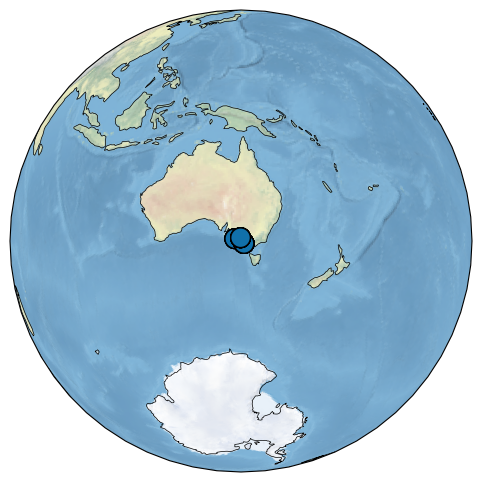

In [29]:
mgs = pyleo.MultipleGeoSeries(gs_list)

fix, ax = mgs.map(legend = True)

And let's plot the timeseries!

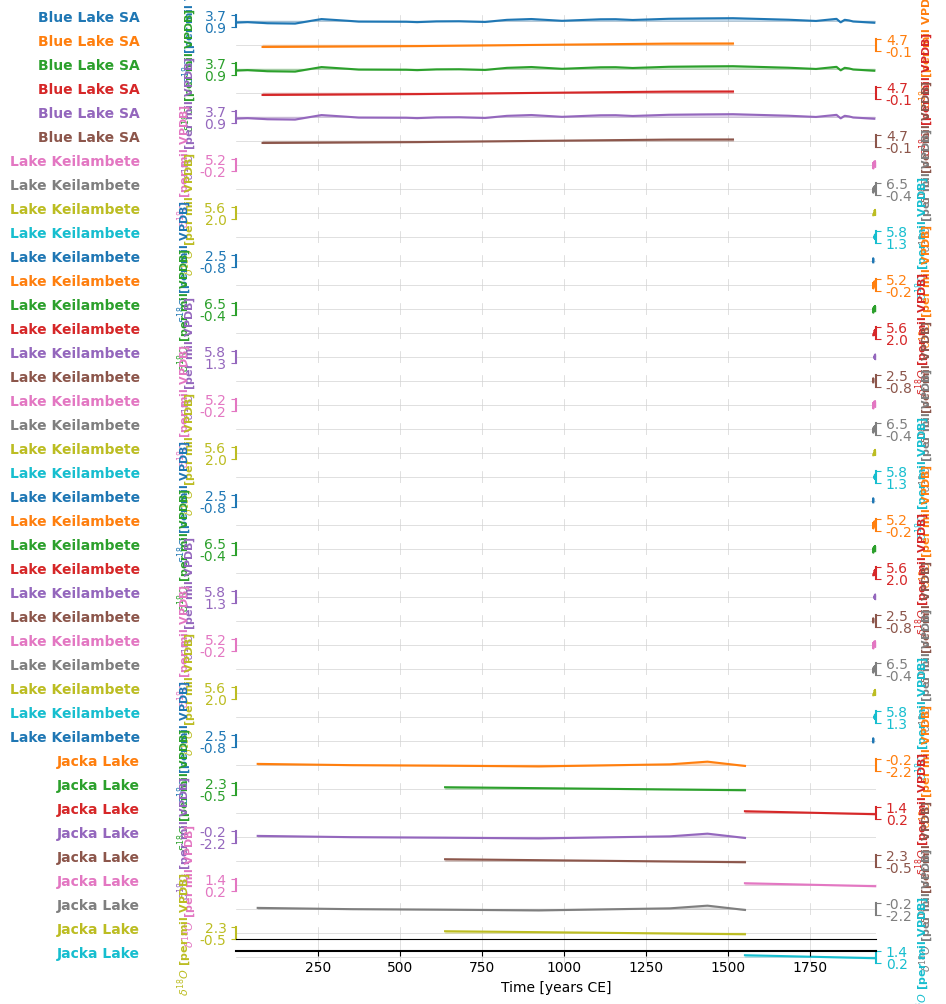

In [34]:
fix,ax = mgs.stackplot(v_shift_factor = 2)

Many of these records are short! 